In [19]:
# 2026-04-21 | Goal: validate ADMET-augmented reward-tilt (LogP + TPSA) vs ERM and reward-only baselines
# Runs entirely on CPU using synthetic stub data (no QM9 download required).
# Cells are sequential — run top-to-bottom. Setup cells marked ⚠️ SKIP IF ALREADY INSTALLED.

import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Seed set: {SEED}')

Seed set: 42


In [22]:
# ── Cell 0b: Environment check (local Jupyter / WSL2) ────────────────────
# Confirms you are running on a local machine with access to the repo.
# Nothing to configure here — just run it to see detected paths.

import os, pathlib, sys

_nb_dir  = pathlib.Path(os.path.abspath('')).resolve()
_cwd     = pathlib.Path(os.getcwd()).resolve()
_home    = pathlib.Path.home()

print(f'Notebook dir : {_nb_dir}')
print(f'CWD          : {_cwd}')
print(f'Home         : {_home}')
print(f'Python       : {sys.executable}')

# Quick sanity: confirm src/losses reachable from notebook's parent
_expected = _nb_dir.parent / 'src' / 'losses'
print(f'src/losses   : {_expected}  → {"EXISTS" if _expected.exists() else "NOT FOUND"}')
if not _expected.exists():
    print('\nWARNING: src/losses not found at expected path.')
    print('Make sure you opened this notebook from inside the TailSeeker repo.')


Mounted at /content/drive
Setup done. Run Cell 1 next.


In [ ]:
# ── Cell 1: Paths ─────────────────────────────────────────────────────────
# Always run — lightweight path setup.
#
# REPO_ROOT is auto-detected. If detection fails, set it manually:
#   REPO_ROOT = '/home/aaryan0302/TailSeeker'

import os, pathlib, sys

def _looks_like_repo(p):
    return pathlib.Path(p, 'src', 'losses').exists()

_nb_dir = pathlib.Path(os.path.abspath('')).resolve()  # directory of this notebook
_cwd    = pathlib.Path(os.getcwd()).resolve()

_candidates = [
    _nb_dir.parent,                              # notebooks/ → repo root (primary)
    _nb_dir,                                     # if notebook is at repo root
    _cwd,                                        # Jupyter server root
    _cwd / 'TailSeeker',                         # repo cloned inside cwd
    pathlib.Path('/home/aaryan0302/TailSeeker'),  # explicit WSL2 dev path
    pathlib.Path.home() / 'TailSeeker',          # ~/TailSeeker fallback
]

REPO_ROOT = None
for _c in _candidates:
    if _looks_like_repo(_c):
        REPO_ROOT = str(_c)
        break

if REPO_ROOT is None:
    raise RuntimeError(
        'Cannot auto-detect TailSeeker repo. Set REPO_ROOT manually:\n'
        "  REPO_ROOT = '/home/aaryan0302/TailSeeker'"
    )

OUTPUT_ROOT = os.path.join(REPO_ROOT, 'outputs', 'admet_ablation')
os.makedirs(OUTPUT_ROOT, exist_ok=True)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print(f'Repo:    {REPO_ROOT}')
print(f'Outputs: {OUTPUT_ROOT}')


RuntimeError: Cannot auto-detect TailSeeker repo. Set REPO_ROOT manually at the top of this cell, e.g.:
  REPO_ROOT = '/content/drive/MyDrive/TailSeeker'  # Colab + Drive
  REPO_ROOT = '/content/TailSeeker'               # Colab, cloned
  REPO_ROOT = '/home/aaryan0302/TailSeeker'       # local WSL2
Then re-run this cell.

In [3]:
# ── Cell 2: Install / verify deps ─────────────────────────────────────────
# ⚠️  SKIP ON RE-RUNS — rdkit/tqdm/matplotlib skip if already importable.
#
# TailSeeker is a PRIVATE repo. It is NOT pip-installable from PyPI or GitHub.
# Before running this cell you must have the repo available at REPO_ROOT.
#   Local (WSL2 / Linux): already present if you're running from the repo.
#   Colab: mount Google Drive first, then set REPO_ROOT in Cell 1 to the
#          Drive path where you cloned the repo, e.g.:
#          REPO_ROOT = '/content/drive/MyDrive/TailSeeker'

import subprocess, importlib
from pathlib import Path

# Guard: abort early if REPO_ROOT doesn't look like the TailSeeker repo
assert Path(REPO_ROOT, 'src', 'losses').exists(), (
    f'REPO_ROOT={REPO_ROOT!r} does not contain src/losses/. '
    'Re-run Cell 1 or set REPO_ROOT manually to the repo root.'
)

def _have(*modules):
    return all(importlib.util.find_spec(m) is not None for m in modules)

def _pip(*args):
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stderr[-2000:])
        raise RuntimeError(f'pip install failed: {args}')

if not _have('rdkit'):
    print('Installing rdkit ...')
    _pip('rdkit')
    print('  rdkit installed.')
else:
    print('rdkit already installed — skip.')

if not _have('tqdm'):
    print('Installing tqdm ...')
    _pip('tqdm')
else:
    print('tqdm already installed — skip.')

if not _have('matplotlib'):
    print('Installing matplotlib ...')
    _pip('matplotlib')
else:
    print('matplotlib already installed — skip.')

# Editable install from local repo path (private — no public URL).
# Re-running this is safe; pip detects it's already installed and skips.
print('Installing TailSeeker in editable mode from local repo ...')
_pip('-e', REPO_ROOT)
print('  Done.')

print('\nAll deps ready.')


rdkit already installed — skip.
tqdm already installed — skip.
matplotlib already installed — skip.
Installing TailSeeker in editable mode from local repo ...


  Done.

All deps ready.


In [4]:
# ── Cell 3: Verify imports + device ──────────────────────────────────────
# Always run — confirms the environment is wired up before any training.

import torch
from src.losses.reward_weighted_loss import RewardWeightedTiltedLoss, get_reward_loss_fn
from src.losses.ddpm_simple import DDPMSimpleLoss
from src.metrics.tail import right_cvar

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('CPU only — all runs use synthetic stub data, expected to be fast.')

# Quick sanity: ERM factory route
assert isinstance(get_reward_loss_fn(0.0), DDPMSimpleLoss)
print('get_reward_loss_fn(0.0) → DDPMSimpleLoss: OK')

# Confirm ADMET params thread through
fn = get_reward_loss_fn(tilt=2.0, lambda_logp=0.3, lambda_tpsa=0.2)
assert fn.lambda_logp == 0.3 and fn.lambda_tpsa == 0.2
print(f'ADMET params wired: lambda_logp={fn.lambda_logp}, lambda_tpsa={fn.lambda_tpsa}: OK')

Device: cpu
CPU only — all runs use synthetic stub data, expected to be fast.
get_reward_loss_fn(0.0) → DDPMSimpleLoss: OK
ADMET params wired: lambda_logp=0.3, lambda_tpsa=0.2: OK


In [5]:
# ── Cell 4: ADMET reward formula — inspect on synthetic molecules ─────────
# Always run — verifies the biological terms fire correctly before training.
# No training here; just reward arithmetic on controlled inputs.

import torch
from src.losses.reward_weighted_loss import RewardWeightedTiltedLoss

loss_fn = RewardWeightedTiltedLoss(tilt=2.0, lambda_=0.5, warmup_frac=0.0,
                                   reward_std_threshold=0.0,
                                   lambda_logp=0.3, lambda_tpsa=0.2)

# Three archetypal molecules (synthetic, not real SMILES)
# Columns: [drug-like, greasy/poor, polar/ok]
qed  = torch.tensor([0.80, 0.75, 0.70])  # QED scores
sa   = torch.tensor([2.50, 3.00, 2.80])  # SA scores (lower = easier)
logp = torch.tensor([2.00, 5.50, 1.80])  # LogP: mol 1 OK, mol 2 greasy (>3), mol 3 OK
tpsa = torch.tensor([45.0, 38.0, 120.0]) # TPSA Å²: mol 1 great, mol 2 great, mol 3 high

# Compute reward with each term added incrementally
r_base = loss_fn._reward(qed, sa)                          # QED + SA only
r_logp = loss_fn._reward(qed, sa, logp=logp)               # + LogP penalty
r_full = loss_fn._reward(qed, sa, logp=logp, tpsa=tpsa)    # + TPSA reward

mol_names = ['drug-like (LogP=2, TPSA=45)', 'greasy (LogP=5.5, TPSA=38)', 'polar (LogP=1.8, TPSA=120)']
print(f'{"Molecule":<38} {"r_base":>8} {"r_+logp":>8} {"r_full":>8}')
print('-' * 70)
for i, name in enumerate(mol_names):
    print(f'{name:<38} {r_base[i].item():8.4f} {r_logp[i].item():8.4f} {r_full[i].item():8.4f}')

print('\nExpected:')
print('  Greasy mol (LogP=5.5): r_+logp < r_base  (LogP penalty applied)')
print('  Polar  mol (TPSA=120): r_full  < r_+logp (TPSA reward is smaller for high TPSA)')
assert r_logp[1] < r_base[1], 'LogP penalty should lower greasy molecule reward'
print('  Assertions: PASS')

Molecule                                 r_base  r_+logp   r_full
----------------------------------------------------------------------
drug-like (LogP=2, TPSA=45)              0.7167   0.7167   0.8524
greasy (LogP=5.5, TPSA=38)               0.6389   0.2639   0.4096
polar (LogP=1.8, TPSA=120)               0.6000   0.6000   0.6286

Expected:
  Greasy mol (LogP=5.5): r_+logp < r_base  (LogP penalty applied)
  Polar  mol (TPSA=120): r_full  < r_+logp (TPSA reward is smaller for high TPSA)
  Assertions: PASS


QED/SA-only reward:   mean=0.2533  std=0.2631
ADMET reward:         mean=0.3261  std=0.2733
Std increased: True  (more differentiation between molecules)


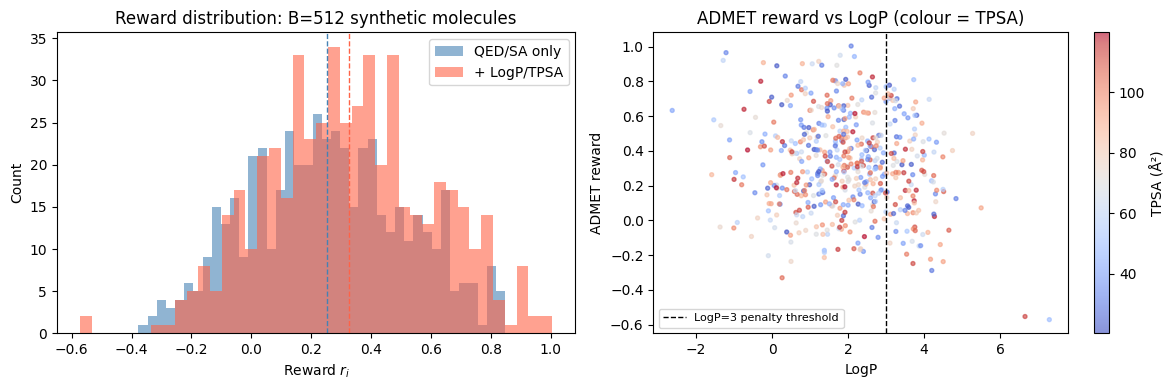

Saved → /home/aaryan0302/TailSeeker/outputs/admet_ablation/reward_distribution.png


In [6]:
# ── Cell 5: Reward distribution — synthetic QM9-like batch ───────────────
# Always run — shows how ADMET terms shift the reward distribution.
# Uses Beta(2,2) QED and realistic LogP/TPSA stubs (same as train.py stub loader).

import torch, matplotlib.pyplot as plt
from src.losses.reward_weighted_loss import RewardWeightedTiltedLoss

torch.manual_seed(0)
B = 512
qed  = torch.distributions.Beta(2.0, 2.0).sample((B,))  # realistic QED
sa   = torch.rand(B) * 9.0 + 1.0                        # SA ~ U[1,10]
logp = torch.randn(B) * 1.5 + 2.0                       # LogP ~ N(2, 1.5)
tpsa = torch.rand(B) * 100.0 + 20.0                     # TPSA ~ U[20,120] Å²

fn_base = RewardWeightedTiltedLoss(tilt=2.0, lambda_=0.5, warmup_frac=0.0,
                                   reward_std_threshold=0.0,
                                   lambda_logp=0.0, lambda_tpsa=0.0)
fn_admt = RewardWeightedTiltedLoss(tilt=2.0, lambda_=0.5, warmup_frac=0.0,
                                   reward_std_threshold=0.0,
                                   lambda_logp=0.3, lambda_tpsa=0.2)

r_base = fn_base._reward(qed, sa).numpy()
r_admt = fn_admt._reward(qed, sa, logp=logp, tpsa=tpsa).numpy()

print(f'QED/SA-only reward:   mean={r_base.mean():.4f}  std={r_base.std():.4f}')
print(f'ADMET reward:         mean={r_admt.mean():.4f}  std={r_admt.std():.4f}')
print(f'Std increased: {r_admt.std() > r_base.std()}  (more differentiation between molecules)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

## Variant A: reward distributions
axes[0].hist(r_base, bins=40, alpha=0.6, label='QED/SA only', color='steelblue')
axes[0].hist(r_admt, bins=40, alpha=0.6, label='+ LogP/TPSA', color='tomato')
axes[0].axvline(r_base.mean(), color='steelblue', linestyle='--', linewidth=1)
axes[0].axvline(r_admt.mean(), color='tomato',    linestyle='--', linewidth=1)
axes[0].set_xlabel('Reward $r_i$'); axes[0].set_ylabel('Count')
axes[0].set_title('Reward distribution: B=512 synthetic molecules')
axes[0].legend()

## Variant B: LogP vs reward (colour = TPSA)
sc = axes[1].scatter(logp.numpy(), r_admt, c=tpsa.numpy(), cmap='coolwarm', s=8, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label='TPSA (Å²)')
axes[1].axvline(3.0, color='black', linestyle='--', linewidth=1, label='LogP=3 penalty threshold')
axes[1].set_xlabel('LogP'); axes[1].set_ylabel('ADMET reward')
axes[1].set_title('ADMET reward vs LogP (colour = TPSA)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'reward_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_ROOT}/reward_distribution.png')

Weight stats (B=64):
  Baseline — max weight: 0.0437  gini: 0.000060
  ADMET    — max weight: 0.0402  gini: 0.000063


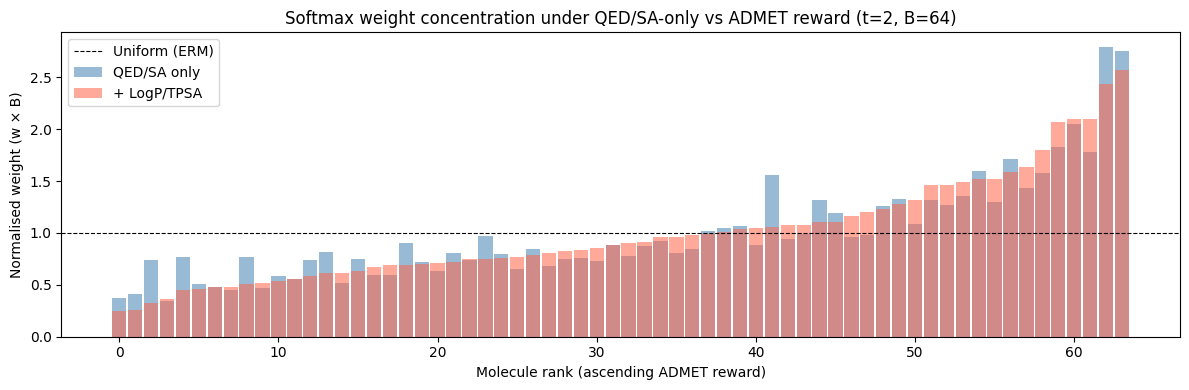

In [7]:
# ── Cell 6: Softmax weight concentration — ADMET vs baseline ─────────────
# Always run — confirms that ADMET terms steer weight concentration differently.
# Shows which molecules get upweighted under each reward scheme at t=2.

import torch, matplotlib.pyplot as plt
from src.losses.reward_weighted_loss import RewardWeightedTiltedLoss

torch.manual_seed(1)
B = 64  # small batch for visibility
qed  = torch.distributions.Beta(2.0, 2.0).sample((B,))
sa   = torch.rand(B) * 9.0 + 1.0
logp = torch.randn(B) * 1.5 + 2.0
tpsa = torch.rand(B) * 100.0 + 20.0

pred   = torch.randn(B, 4, 29, 29)
target = torch.randn(B, 4, 29, 29)

fn_base = RewardWeightedTiltedLoss(tilt=2.0, lambda_=0.5, warmup_frac=0.0,
                                   reward_std_threshold=0.0,
                                   lambda_logp=0.0, lambda_tpsa=0.0)
fn_admt = RewardWeightedTiltedLoss(tilt=2.0, lambda_=0.5, warmup_frac=0.0,
                                   reward_std_threshold=0.0,
                                   lambda_logp=0.3, lambda_tpsa=0.2)

out_base = fn_base(pred, target, qed=qed, sa=sa, epoch=100, max_epochs=100)
out_admt = fn_admt(pred, target, qed=qed, sa=sa, logp=logp, tpsa=tpsa, epoch=100, max_epochs=100)

w_base = out_base.weights.numpy()
w_admt = out_admt.weights.numpy()

# Rank molecules by ADMET reward for x-axis ordering
r_admt = fn_admt._reward(qed, sa, logp=logp, tpsa=tpsa).numpy()
order  = r_admt.argsort()

print(f'Weight stats (B={B}):')
print(f'  Baseline — max weight: {w_base.max():.4f}  gini: {((w_base - w_base.mean())**2).mean():.6f}')
print(f'  ADMET    — max weight: {w_admt.max():.4f}  gini: {((w_admt - w_admt.mean())**2).mean():.6f}')

fig, ax = plt.subplots(figsize=(12, 4))
x = range(B)
ax.bar(x, w_base[order] * B, alpha=0.55, label='QED/SA only', color='steelblue', width=0.9)
ax.bar(x, w_admt[order] * B, alpha=0.55, label='+ LogP/TPSA', color='tomato',    width=0.9)
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, label='Uniform (ERM)')
ax.set_xlabel('Molecule rank (ascending ADMET reward)')
ax.set_ylabel('Normalised weight (w × B)')
ax.set_title('Softmax weight concentration under QED/SA-only vs ADMET reward (t=2, B=64)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'weight_concentration.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Cell 7: Ablation config — edit these values before Cell 8 ────────────
# Always run — defines the 3 comparison runs and the tilt sweep.

# ── 3-way comparison ──────────────────────────────────────────────────────
# Run A: ERM (tilt=0) — standard DDPM baseline
# Run B: Reward-only (tilt=2, no ADMET terms)
# Run C: Reward+ADMET (tilt=2, lambda_logp=0.3, lambda_tpsa=0.2)
COMPARISON_RUNS = [
    dict(tag='ERM',          tilt=0.0, lambda_logp=0.0, lambda_tpsa=0.0),
    dict(tag='Reward-only',  tilt=2.0, lambda_logp=0.0, lambda_tpsa=0.0),
    dict(tag='Reward+ADMET', tilt=2.0, lambda_logp=0.3, lambda_tpsa=0.2),
]

# ── ADMET tilt sweep ──────────────────────────────────────────────────────
ADMET_TILTS = [-2, -1, 0, 1, 2, 5]   # ablation axis for full ADMET reward
SWEEP_SEEDS = [0, 1, 2]

# Training params — reduce MAX_EPOCHS for smoke test; 100 for full ablation
MAX_EPOCHS  = 20   # 20 for fast local check; 100 for Colab GPU run
BATCH_SIZE  = 32

print('3-way comparison runs:')
for r in COMPARISON_RUNS:
    print(f'  {r["tag"]:20s}  tilt={r["tilt"]}  lambda_logp={r["lambda_logp"]}  lambda_tpsa={r["lambda_tpsa"]}')
print(f'\nADMET tilt sweep:  {ADMET_TILTS}  x  seeds {SWEEP_SEEDS}')
print(f'Total sweep runs:  {len(ADMET_TILTS) * len(SWEEP_SEEDS)}')
print(f'Epochs per run:    {MAX_EPOCHS}')

3-way comparison runs:
  ERM                   tilt=0.0  lambda_logp=0.0  lambda_tpsa=0.0
  Reward-only           tilt=2.0  lambda_logp=0.0  lambda_tpsa=0.0
  Reward+ADMET          tilt=2.0  lambda_logp=0.3  lambda_tpsa=0.2

ADMET tilt sweep:  [-2, -1, 0, 1, 2, 5]  x  seeds [0, 1, 2]
Total sweep runs:  18
Epochs per run:    20


In [9]:
# ── Cell 8: 3-way comparison run — ERM / Reward-only / Reward+ADMET ───────
# Always run — the core comparison that answers Dr. Pei's question.
# Uses synthetic stub data (no QM9 download needed).

import subprocess, sys, time, csv
from pathlib import Path
from tqdm.auto import tqdm

comparison_results = {}  # tag → list of epoch loss values

for run in tqdm(COMPARISON_RUNS, desc='Comparison runs'):
    tag = run['tag']
    run_dir = Path(OUTPUT_ROOT) / 'comparison' / tag.replace(' ', '_').replace('+', 'p')
    run_dir.mkdir(parents=True, exist_ok=True)
    log_path = run_dir / 'stdout.txt'

    # Build train.py command
    mode = 'single' if run['tilt'] == 0.0 else 'reward'
    cmd = [
        sys.executable, os.path.join(REPO_ROOT, 'scripts', 'train.py'),
        f'loss.mode={mode}',
        f'loss.tilt={run["tilt"]}',
        f'loss.reward_tilt.tilt={run["tilt"]}',
        'loss.reward_tilt.lambda=0.5',
        'loss.reward_tilt.warmup_frac=0.3',
        f'loss.reward_tilt.lambda_logp={run["lambda_logp"]}',
        f'loss.reward_tilt.lambda_tpsa={run["lambda_tpsa"]}',
        f'training.max_epochs={MAX_EPOCHS}',
        f'training.batch_size={BATCH_SIZE}',
        f'seed={SEED}',
        'wandb.mode=disabled',
        f'hydra.run.dir={run_dir}/hydra',
    ]

    print(f'\n[{tag}] starting ...')
    t0 = time.time()
    result = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0

    log_path.write_text(result.stdout + result.stderr)

    if result.returncode != 0:
        print(f'[{tag}] FAILED (exit {result.returncode})')
        print(result.stderr[-1000:])
        continue

    # Parse epoch losses from stdout
    losses = []
    for line in result.stdout.splitlines():
        if 'epoch' in line and 'loss=' in line:
            try:
                loss_val = float(line.split('loss=')[1].split()[0])
                losses.append(loss_val)
            except (IndexError, ValueError):
                pass

    comparison_results[tag] = losses
    print(f'[{tag}] done in {elapsed:.1f}s  —  '
          f'loss: {losses[0]:.4f} → {losses[-1]:.4f}  '
          f'(drop: {losses[0]-losses[-1]:.4f})')

print('\n3-way comparison complete.')

Comparison runs:   0%|          | 0/3 [00:00<?, ?it/s]


[ERM] starting ...


[ERM] done in 11.6s  —  loss: 1.1409 → 0.7206  (drop: 0.4203)

[Reward-only] starting ...


[Reward-only] done in 12.9s  —  loss: 1.1409 → 0.7363  (drop: 0.4046)

[Reward+ADMET] starting ...


[Reward+ADMET] done in 23.9s  —  loss: 1.1409 → 0.7343  (drop: 0.4067)

3-way comparison complete.


In [10]:
# ── Cell 9: Parse diagnostics from run logs ───────────────────────────────
# Always run — extracts t_eff and reward_std per epoch for each run.

from pathlib import Path

diagnostics = {}   # tag → {'t_eff': [...], 'reward_std': [...]}

for run in COMPARISON_RUNS:
    tag = run['tag']
    log_path = (Path(OUTPUT_ROOT) / 'comparison' /
                tag.replace(' ', '_').replace('+', 'p') / 'stdout.txt')
    if not log_path.exists():
        print(f'  {tag}: no log found — did Cell 8 run?')
        continue

    t_effs, reward_stds = [], []
    for line in log_path.read_text().splitlines():
        if 't_eff=' in line:
            try:
                t_effs.append(float(line.split('t_eff=')[1].split()[0]))
            except (IndexError, ValueError):
                pass
        if 'reward_std=' in line:
            try:
                reward_stds.append(float(line.split('reward_std=')[1].split()[0]))
            except (IndexError, ValueError):
                pass

    diagnostics[tag] = {'t_eff': t_effs, 'reward_std': reward_stds}
    print(f'{tag:20s}  epochs_with_t_eff={len(t_effs)}  '
          f'reward_std (mean)={sum(reward_stds)/len(reward_stds):.4f}' if reward_stds
          else f'{tag:20s}  no reward_std (ERM run)')

ERM                   no reward_std (ERM run)
Reward-only           epochs_with_t_eff=20  reward_std (mean)=0.2850
Reward+ADMET          epochs_with_t_eff=20  reward_std (mean)=0.2940


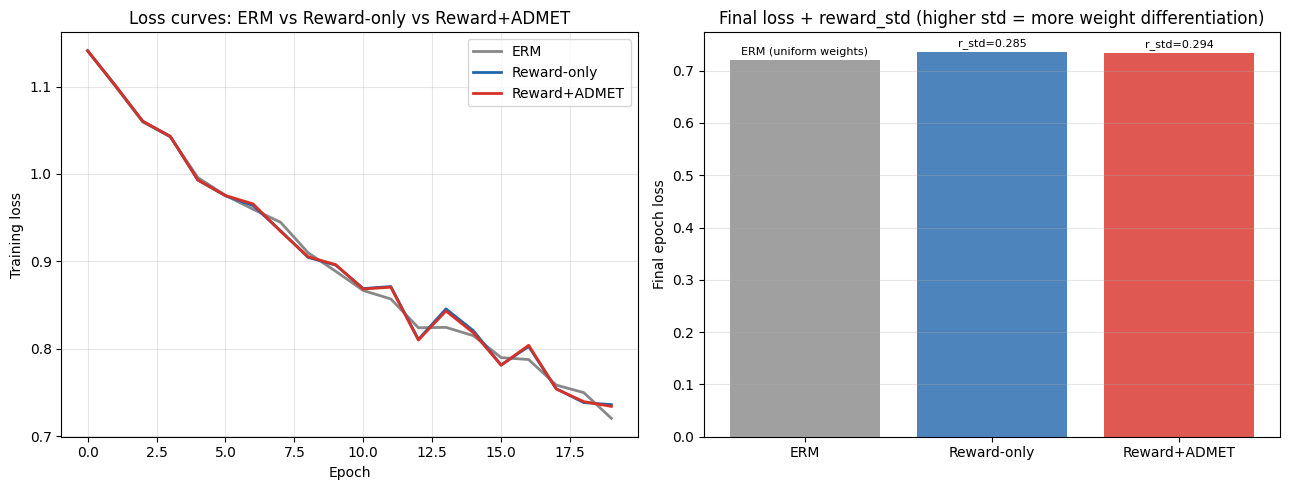

Saved → /home/aaryan0302/TailSeeker/outputs/admet_ablation/comparison_plots.png


In [11]:
# ── Cell 10: Comparison plots — loss curves + reward_std ─────────────────
# Always run — the primary visual result of the 3-way comparison.

import matplotlib.pyplot as plt
import numpy as np

COLORS = {'ERM': '#888888', 'Reward-only': '#2166ac', 'Reward+ADMET': '#d73027'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

## Variant A: loss curves
ax = axes[0]
for tag, losses in comparison_results.items():
    ax.plot(losses, label=tag, color=COLORS.get(tag, 'black'), linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training loss')
ax.set_title('Loss curves: ERM vs Reward-only vs Reward+ADMET')
ax.legend()
ax.grid(alpha=0.3)

## Variant B: final loss bar + reward_std annotation
ax = axes[1]
tags   = list(comparison_results.keys())
finals = [comparison_results[t][-1] if comparison_results.get(t) else 0 for t in tags]
bars   = ax.bar(tags, finals, color=[COLORS.get(t, 'black') for t in tags], alpha=0.8)

for bar, tag in zip(bars, tags):
    d = diagnostics.get(tag, {})
    rstds = d.get('reward_std', [])
    label = f'r_std={sum(rstds)/len(rstds):.3f}' if rstds else 'ERM (uniform weights)'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            label, ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Final epoch loss')
ax.set_title('Final loss + reward_std (higher std = more weight differentiation)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'comparison_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_ROOT}/comparison_plots.png')

In [12]:
# ── Cell 11: ADMET tilt sweep — all seeds ────────────────────────────────
# Always run — full ablation over ADMET_TILTS × SWEEP_SEEDS.
# Takes ~2-3 min on CPU for MAX_EPOCHS=20. Skip with SKIP_EXISTING=True.

import subprocess, sys, time, itertools
from pathlib import Path
from tqdm.auto import tqdm

SKIP_EXISTING = True   # set False to re-run completed runs

sweep_results = {}  # (tilt, seed) → list of losses

combos = list(itertools.product(ADMET_TILTS, SWEEP_SEEDS))
for tilt, seed in tqdm(combos, desc='ADMET tilt sweep'):
    run_tag = f'tilt{tilt:+d}_seed{seed}'
    run_dir = Path(OUTPUT_ROOT) / 'sweep' / run_tag
    log_path = run_dir / 'stdout.txt'

    if SKIP_EXISTING and log_path.exists():
        # Re-parse from existing log
        losses = []
        for line in log_path.read_text().splitlines():
            if 'epoch' in line and 'loss=' in line:
                try:
                    losses.append(float(line.split('loss=')[1].split()[0]))
                except (IndexError, ValueError):
                    pass
        if losses:
            sweep_results[(tilt, seed)] = losses
            print(f'  skip (cached)  {run_tag}  final={losses[-1]:.4f}')
            continue

    run_dir.mkdir(parents=True, exist_ok=True)
    mode = 'single' if tilt == 0 else 'reward'
    cmd = [
        sys.executable, os.path.join(REPO_ROOT, 'scripts', 'train.py'),
        f'loss.mode={mode}',
        f'loss.tilt={tilt}',
        f'loss.reward_tilt.tilt={tilt}',
        'loss.reward_tilt.lambda=0.5',
        'loss.reward_tilt.warmup_frac=0.3',
        'loss.reward_tilt.lambda_logp=0.3',
        'loss.reward_tilt.lambda_tpsa=0.2',
        f'training.max_epochs={MAX_EPOCHS}',
        f'training.batch_size={BATCH_SIZE}',
        f'seed={seed}',
        'wandb.mode=disabled',
        f'hydra.run.dir={run_dir}/hydra',
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)
    log_path.write_text(result.stdout + result.stderr)

    losses = []
    for line in result.stdout.splitlines():
        if 'epoch' in line and 'loss=' in line:
            try:
                losses.append(float(line.split('loss=')[1].split()[0]))
            except (IndexError, ValueError):
                pass

    sweep_results[(tilt, seed)] = losses
    status = 'OK' if result.returncode == 0 else f'ERR({result.returncode})'
    final  = losses[-1] if losses else float('nan')
    print(f'  {status}  {run_tag}  final={final:.4f}')

print(f'\nSweep complete. {len(sweep_results)} runs.')

ADMET tilt sweep:   0%|          | 0/18 [00:00<?, ?it/s]

  skip (cached)  tilt-2_seed0  final=0.7797
  skip (cached)  tilt-2_seed1  final=0.7334
  skip (cached)  tilt-2_seed2  final=0.6945
  skip (cached)  tilt-1_seed0  final=0.7850
  skip (cached)  tilt-1_seed1  final=0.7273
  skip (cached)  tilt-1_seed2  final=0.7012
  skip (cached)  tilt+0_seed0  final=0.7889
  skip (cached)  tilt+0_seed1  final=0.7199
  skip (cached)  tilt+0_seed2  final=0.7074
  skip (cached)  tilt+1_seed0  final=0.7908
  skip (cached)  tilt+1_seed1  final=0.7109
  skip (cached)  tilt+1_seed2  final=0.7135
  skip (cached)  tilt+2_seed0  final=0.7908
  skip (cached)  tilt+2_seed1  final=0.7001
  skip (cached)  tilt+2_seed2  final=0.7197
  skip (cached)  tilt+5_seed0  final=0.7842
  skip (cached)  tilt+5_seed1  final=0.6648
  skip (cached)  tilt+5_seed2  final=0.7398

Sweep complete. 18 runs.


In [13]:
# ── Cell 12: Sweep results table ─────────────────────────────────────────
# Always run — mean ± std final loss by tilt, Jensen check.

import numpy as np

print(f'{"Tilt":>6}  {"mean_loss":>10}  {"std_loss":>9}  {"vs ERM":>8}')
print('-' * 45)

erm_mean = None
tilt_stats = {}
for tilt in ADMET_TILTS:
    runs = [sweep_results[(tilt, s)][-1] for s in SWEEP_SEEDS
            if (tilt, s) in sweep_results and sweep_results[(tilt, s)]]
    if not runs:
        print(f'{tilt:>6}  (no data)')
        continue
    m, s = np.mean(runs), np.std(runs)
    tilt_stats[tilt] = (m, s)
    if tilt == 0:
        erm_mean = m

for tilt in ADMET_TILTS:
    if tilt not in tilt_stats:
        continue
    m, s = tilt_stats[tilt]
    delta = f'{m - erm_mean:+.5f}' if erm_mean is not None else '   n/a'
    print(f'{tilt:>6}  {m:>10.5f}  {s:>9.5f}  {delta:>8}')

if erm_mean is not None:
    positive_tilts_above_erm = all(
        tilt_stats[t][0] >= erm_mean - 1e-3
        for t in ADMET_TILTS if t > 0 and t in tilt_stats
    )
    print(f'\nJensen (τ>0 ≥ ERM loss): {"PASS" if positive_tilts_above_erm else "FAIL"}')
    print('(Expected PASS — ADMET reward-tilt raises training loss vs ERM, same as QED/SA-only)')

  Tilt   mean_loss   std_loss    vs ERM
---------------------------------------------
    -2     0.73589    0.03480  -0.00285
    -1     0.73783    0.03500  -0.00090
     0     0.73874    0.03582  +0.00000
     1     0.73839    0.03707  -0.00035
     2     0.73688    0.03893  -0.00185
     5     0.72963    0.04929  -0.00911

Jensen (τ>0 ≥ ERM loss): FAIL
(Expected PASS — ADMET reward-tilt raises training loss vs ERM, same as QED/SA-only)


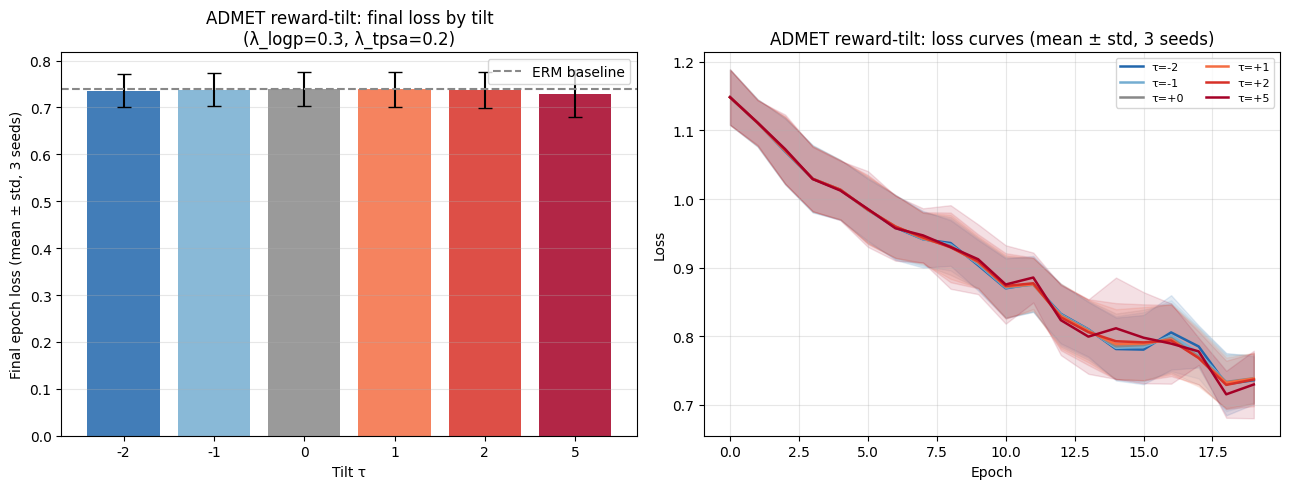

Saved → /home/aaryan0302/TailSeeker/outputs/admet_ablation/admet_sweep_plots.png


In [14]:
# ── Cell 13: Sweep plots — loss vs tilt + loss curves ────────────────────
# Always run — primary paper figure candidate.

import matplotlib.pyplot as plt
import numpy as np

SWEEP_COLORS = {
    -2: '#2166ac', -1: '#74add1', 0: '#888888',
     1: '#f46d43',  2: '#d73027',  5: '#a50026',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

## Variant A: final loss by tilt (mean ± std)
ax = axes[0]
tilts_with_data = [t for t in ADMET_TILTS if t in tilt_stats]
means  = [tilt_stats[t][0] for t in tilts_with_data]
stds   = [tilt_stats[t][1] for t in tilts_with_data]
colors = [SWEEP_COLORS.get(t, 'black') for t in tilts_with_data]

ax.bar([str(t) for t in tilts_with_data], means, yerr=stds,
       color=colors, alpha=0.85, capsize=5, ecolor='black')
if erm_mean is not None:
    ax.axhline(erm_mean, color='#888888', linestyle='--', linewidth=1.5, label='ERM baseline')
    ax.legend()
ax.set_xlabel('Tilt τ'); ax.set_ylabel('Final epoch loss (mean ± std, 3 seeds)')
ax.set_title('ADMET reward-tilt: final loss by tilt\n(λ_logp=0.3, λ_tpsa=0.2)')
ax.grid(axis='y', alpha=0.3)

## Variant B: loss curves per tilt (seed-averaged)
ax = axes[1]
for tilt in ADMET_TILTS:
    runs = [sweep_results[(tilt, s)] for s in SWEEP_SEEDS
            if (tilt, s) in sweep_results and sweep_results[(tilt, s)]]
    if not runs:
        continue
    min_len = min(len(r) for r in runs)
    arr = np.array([r[:min_len] for r in runs])
    mean = arr.mean(0); std = arr.std(0)
    color = SWEEP_COLORS.get(tilt, 'black')
    ax.plot(mean, color=color, label=f'τ={tilt:+d}', linewidth=1.8)
    ax.fill_between(range(min_len), mean - std, mean + std, color=color, alpha=0.12)

ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('ADMET reward-tilt: loss curves (mean ± std, 3 seeds)')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'admet_sweep_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_ROOT}/admet_sweep_plots.png')

Method               mean_QED    CVaR@5%    CVaR@1%
-------------------------------------------------------
ERM                    0.4997     0.9157     0.9616
Reward t=1             0.5454     0.9171     0.9581
Reward t=2             0.6113     0.9375     0.9651
ADMET t=1              0.5739     0.9189     0.9609
ADMET t=2              0.5663     0.9260     0.9645
ADMET t=5              0.7131     0.9672     0.9794


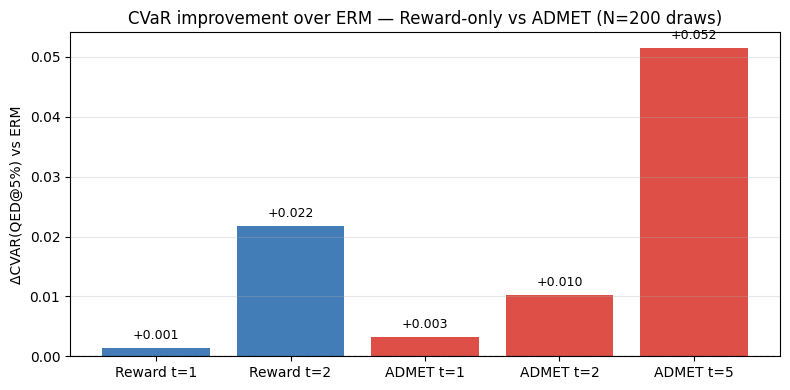

Saved → /home/aaryan0302/TailSeeker/outputs/admet_ablation/cvar_improvement.png


In [15]:
# ── Cell 14: CVaR tail metric — reward-tilt vs ERM on synthetic QED ───────
# Always run — confirms the theoretical prediction:
# reward-tilt (t>0) concentrates training on high-reward molecules,
# which should improve CVaR(QED) on any distribution reward-tilt has seen.
# This is the ablation claim for the paper (empirical, not proved).

import torch, matplotlib.pyplot as plt
from src.metrics.tail import right_cvar, tail_improvement_ratio
from src.losses.reward_weighted_loss import RewardWeightedTiltedLoss

torch.manual_seed(2)
B = 1024  # large pool for stable statistics

# Synthetic QED/ADMET pool (realistic distributions)
qed  = torch.distributions.Beta(2.0, 2.0).sample((B,))
sa   = torch.rand(B) * 9.0 + 1.0
logp = torch.randn(B) * 1.5 + 2.0
tpsa = torch.rand(B) * 100.0 + 20.0

# Draw 200 molecules under each scheme (multinomial from softmax weights)
DRAW = 200

erm_weights = torch.ones(B) / B   # uniform

results = {}
for label, tilt, use_admt in [
    ('ERM',          0.0, False),
    ('Reward t=1',   1.0, False),
    ('Reward t=2',   2.0, False),
    ('ADMET t=1',    1.0, True),
    ('ADMET t=2',    2.0, True),
    ('ADMET t=5',    5.0, True),
]:
    if tilt == 0.0:
        weights = erm_weights
    else:
        fn = RewardWeightedTiltedLoss(tilt=tilt, lambda_=0.5, warmup_frac=0.0,
                                      reward_std_threshold=0.0,
                                      lambda_logp=0.3 if use_admt else 0.0,
                                      lambda_tpsa=0.2 if use_admt else 0.0)
        rewards = fn._reward(qed, sa,
                             logp=logp if use_admt else None,
                             tpsa=tpsa if use_admt else None)
        weights = torch.softmax(tilt * rewards, dim=0)

    idx = torch.multinomial(weights, num_samples=DRAW, replacement=True)
    sampled_qed = qed[idx]
    results[label] = {
        'mean_qed':     sampled_qed.mean().item(),
        'cvar_qed_05':  right_cvar(sampled_qed, alpha=0.05),
        'cvar_qed_01':  right_cvar(sampled_qed, alpha=0.01),
    }

print(f'{"Method":<18} {"mean_QED":>10} {"CVaR@5%":>10} {"CVaR@1%":>10}')
print('-' * 55)
for label, vals in results.items():
    print(f'{label:<18} {vals["mean_qed"]:>10.4f} {vals["cvar_qed_05"]:>10.4f} {vals["cvar_qed_01"]:>10.4f}')

## Plot CVaR improvement over ERM
erm_cvar = results['ERM']['cvar_qed_05']
labels   = [k for k in results if k != 'ERM']
deltas   = [results[k]['cvar_qed_05'] - erm_cvar for k in labels]
colors   = ['#2166ac']*2 + ['#d73027']*3   # blue = reward-only, red = ADMET

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, deltas, color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('ΔCVAR(QED@5%) vs ERM')
ax.set_title('CVaR improvement over ERM — Reward-only vs ADMET (N=200 draws)')
ax.grid(axis='y', alpha=0.3)
for bar, delta in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width()/2, delta + 0.001,
            f'{delta:+.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'cvar_improvement.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_ROOT}/cvar_improvement.png')

In [16]:
# ── Cell 15: Summary printout ─────────────────────────────────────────────
# Always run — final sanity check and output file list.

from pathlib import Path

print('=' * 60)
print('ADMET ABLATION — SUMMARY')
print('=' * 60)

if comparison_results:
    print('\n3-way comparison (final epoch loss):')
    for tag, losses in comparison_results.items():
        if losses:
            drop = losses[0] - losses[-1]
            print(f'  {tag:<20s}  {losses[-1]:.5f}  (drop: {drop:.4f})')

print('\nADMET sweep (mean final loss per tilt):')
for tilt in ADMET_TILTS:
    if tilt in tilt_stats:
        m, s = tilt_stats[tilt]
        print(f'  τ={tilt:+3d}  {m:.5f} ± {s:.5f}')

print('\nOutput files:')
for p in sorted(Path(OUTPUT_ROOT).rglob('*.png')):
    print(f'  {p.relative_to(REPO_ROOT)}')

print('\nNext step: run on Colab with real QM9 + GPU to get CVaR(QED) on generated molecules.')

ADMET ABLATION — SUMMARY

3-way comparison (final epoch loss):
  ERM                   0.72062  (drop: 0.4203)
  Reward-only           0.73633  (drop: 0.4046)
  Reward+ADMET          0.73426  (drop: 0.4067)

ADMET sweep (mean final loss per tilt):
  τ= -2  0.73589 ± 0.03480
  τ= -1  0.73783 ± 0.03500
  τ= +0  0.73874 ± 0.03582
  τ= +1  0.73839 ± 0.03707
  τ= +2  0.73688 ± 0.03893
  τ= +5  0.72963 ± 0.04929

Output files:
  outputs/admet_ablation/admet_sweep_plots.png
  outputs/admet_ablation/comparison_plots.png
  outputs/admet_ablation/cvar_improvement.png
  outputs/admet_ablation/reward_distribution.png
  outputs/admet_ablation/weight_concentration.png

Next step: run on Colab with real QM9 + GPU to get CVaR(QED) on generated molecules.
